In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import os

Thresh = 13 #Out Of 20
DivNorm1=0
DivNorm2=1

num_positions=30
num_neurons=1000

In [2]:
import importlib
import utils
importlib.reload(utils)

activations_combined_list = []
positions_Arena_combined_list = []
positions_Room_combined_list = []

for seed in range(1):
    np.random.seed(seed)

    # --- Generate all stimulus gains
    StimulusGains1 = np.random.uniform(0, 1, num_positions)
    StimulusGains2 = np.random.uniform(0, 1, num_positions)
    StimulusGains3 = np.random.uniform(0, 1, num_positions)
    StimulusGains4 = np.random.uniform(0, 1, num_positions)
    StimulusGains5 = np.random.uniform(0, 1, num_positions)
    StimulusGains6 = np.random.uniform(0, 1, num_positions)

    # --- Run all cases
    Inputs=10000 #Input Neurons
    CPTM_all_Pos1, _, Indices_Pos1 = utils.run_case(StimulusGains1, Inputs, DivNorm1, PositionCorrelation=5, corr_strength=0)
    CPTM_all_Pos2, _, Indices_Pos2 = utils.run_case(StimulusGains2, Inputs, DivNorm1, PositionCorrelation=5, corr_strength=0)
    Inputs=1000
    CPTM_all_Obj1, _, Indices_Obj1 = utils.run_case(StimulusGains3, Inputs, DivNorm1, PositionCorrelation=0, corr_strength=0)
    CPTM_all_Obj2, _, Indices_Obj2 = utils.run_case(StimulusGains4, Inputs, DivNorm1, PositionCorrelation=0, corr_strength=0)
    CPTM_all_Obj_Room, _, Indices_Obj_Room = utils.run_case(StimulusGains5, Inputs, DivNorm1, PositionCorrelation=0, corr_strength=0)
    CPTM_all_Obj_Room2, _, Indices_Obj_Room2 = utils.run_case(StimulusGains6, Inputs, DivNorm1, PositionCorrelation=0, corr_strength=0)

    # --- Select inhibition level (index into threshold set)
    Inhibition = 0
    Corr = 0

    MatrixPos_Arena = CPTM_all_Pos1[0][Corr][Inhibition]
    MatrixPos_Room = CPTM_all_Pos2[0][Corr][Inhibition]
    Matrix_Obj1 = CPTM_all_Obj1[0][Corr][Inhibition]

    Matrix_Obj2 = CPTM_all_Obj2[0][Corr][Inhibition]
    Matrix_Obj_Room = CPTM_all_Obj_Room[0][Corr][Inhibition]
    Matrix_Obj_Room2 = CPTM_all_Obj_Room2[0][Corr][Inhibition]

    # -- Simulation Parameters
    T = 1800
    P = num_positions
    velocity = 1
    phase_shift_rate = velocity/3
    Sigma = 0.1

    WeightBackground_Arena = 0.035
    WeightBackground_Room = 0.035
    WeightObj_Arena = 0.15
    WeightObj_Room = 0.15
    ScaleArena = 1
    ScaleRoom = 1
    mix_param = 0.5

    # Weight assignment
    WeightArena = np.ones(num_neurons)
    WeightRoom = np.ones(num_neurons)
    half_n = num_neurons // 2
    WeightArena[half_n:] = 0
    WeightRoom[:half_n] = 0

    WeightArena = (1 - mix_param / 2) * WeightArena + mix_param * np.ones(num_neurons)
    WeightRoom = (1 - mix_param / 2) * WeightRoom + mix_param * np.ones(num_neurons)

    total_weight = WeightArena + WeightRoom
    WeightArena /= total_weight
    WeightRoom /= total_weight
    WeightArena *= ScaleArena
    WeightRoom *= ScaleRoom

    CaseA = list(range(5, 10))
    CaseC = list(range(25, 30))
    obj = 3
    T_A = T // 2
    T_C = T - T_A

    # --- Landmark In Position A
    MultiMatrix_Arena_A = MatrixPos_Arena.copy()
    MultiMatrix_Arena_A += WeightBackground_Arena * Matrix_Obj1
    MultiMatrix_Arena_A[:, CaseA] += (WeightObj_Arena * Matrix_Obj2[:, obj])[:, np.newaxis]

    MultiMatrix_Room_A = MatrixPos_Room.copy()
    MultiMatrix_Room_A += WeightBackground_Room * Matrix_Obj_Room
    MultiMatrix_Room_A[:, CaseA] += (WeightObj_Room * Matrix_Obj_Room2[:, obj])[:, np.newaxis]

    activations_A, positions_Arena_A, positions_Room_A = utils.simulate_neural_activity(
        MultiMatrix_Arena_A, MultiMatrix_Room_A, WeightArena, WeightRoom,
        T_A, velocity, Sigma, phase_shift_rate, DivNorm2, Thresh, {obj: CaseA}
    )

    # --- Landmark In Position C
    MultiMatrix_Arena_C = MatrixPos_Arena.copy()
    MultiMatrix_Arena_C += WeightBackground_Arena * Matrix_Obj1
    MultiMatrix_Arena_C[:, CaseC] += (WeightObj_Arena * Matrix_Obj2[:, obj])[:, np.newaxis]

    MultiMatrix_Room_C = MatrixPos_Room.copy()
    MultiMatrix_Room_C += WeightBackground_Room * Matrix_Obj_Room
    MultiMatrix_Room_C[:, CaseC] += (WeightObj_Room * Matrix_Obj_Room2[:, obj])[:, np.newaxis]

    activations_C, positions_Arena_C, positions_Room_C = utils.simulate_neural_activity(
        MultiMatrix_Arena_C, MultiMatrix_Room_C, WeightArena, WeightRoom,
        T_C, velocity, Sigma, phase_shift_rate, DivNorm2, Thresh, {obj: CaseC}
    )

    # --- Combine and store
    activations_combined = np.concatenate((activations_A, activations_C), axis=1)
    positions_Arena_combined = np.concatenate((positions_Arena_A, positions_Arena_C))
    positions_Room_combined = np.concatenate((positions_Room_A, positions_Room_C))

    activations_combined_list.append(activations_combined)
    positions_Arena_combined_list.append(positions_Arena_combined)
    positions_Room_combined_list.append(positions_Room_combined)


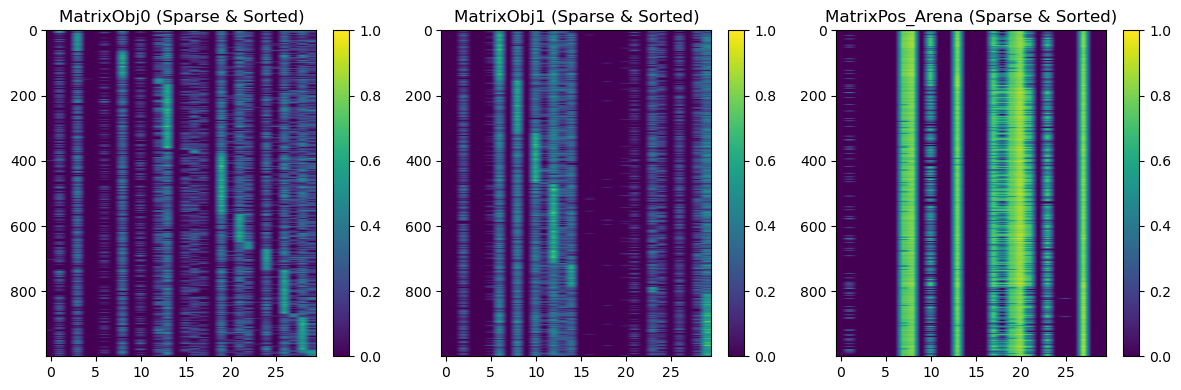

In [25]:
#Sort For Plotting

# Obj0
pref_0 = np.argmax(Matrix_Obj2, axis=1)
idx_0  = np.argsort(pref_0)

# Obj1
pref_1 = np.argmax(Matrix_Obj1, axis=1)
idx_1  = np.argsort(pref_1)

# Arena
pref_A = np.argmax(MatrixPos_Arena, axis=1)
idx_A  = np.argsort(pref_A)

# Preserve Sparsity
thr_0 = utils.find_thresholds(Matrix_Obj2,       N=20)[13]
thr_1 = utils.find_thresholds(Matrix_Obj1,       N=20)[13]
thr_A = utils.find_thresholds(MatrixPos_Arena,  N=20)[13]

Obj0_sparse_sorted = (Matrix_Obj2       * (Matrix_Obj2      >= thr_0))[idx_0, :]
Obj1_sparse_sorted = (Matrix_Obj1       * (Matrix_Obj1      >= thr_1))[idx_1, :]
Arena_sparse_sorted = (MatrixPos_Arena * (MatrixPos_Arena >= thr_A))[idx_A, :]

#Plot

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(Obj0_sparse_sorted, aspect='auto')
plt.title('MatrixObj0 (Sparse & Sorted)')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(Obj1_sparse_sorted, aspect='auto')
plt.title('MatrixObj1 (Sparse & Sorted)')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(Arena_sparse_sorted, aspect='auto')
plt.title('MatrixPos_Arena (Sparse & Sorted)')
plt.colorbar()

plt.tight_layout()
plt.show()


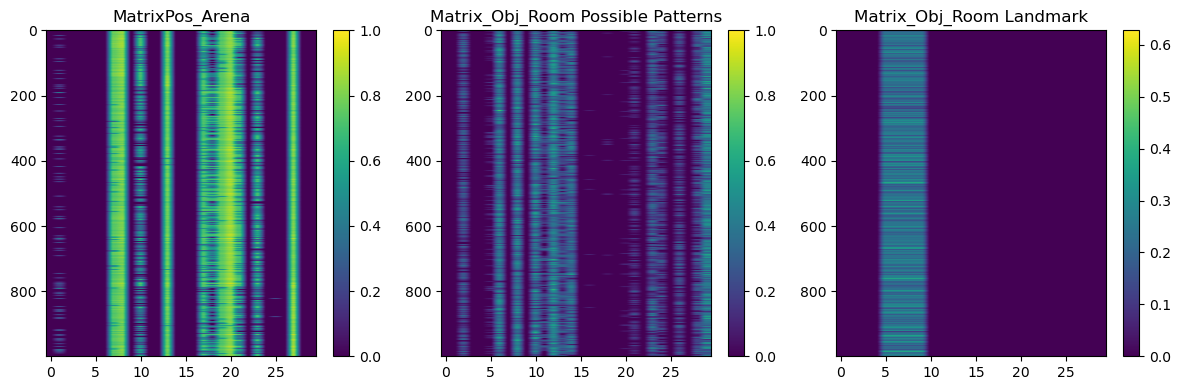

In [31]:
#Sort For Plotting

# Arena
pref_A = np.argmax(MatrixPos_Arena, axis=1)
idx_A  = np.argsort(pref_A)

# Obj1
pref_B = np.argmax(Matrix_Obj_Room, axis=1)
idx_B  = np.argsort(pref_B)

# Room 
Room_single = np.zeros_like(Matrix_Obj_Room)

# Example Landmark, grab pattern from Room Object Matrix, then place in positions 5-9
src_col = 3                 
cols_to_fill = np.arange(5, 10)  
Room_single[:, cols_to_fill] = Matrix_Obj_Room[:, [src_col]]
pref_C = np.argmax(Room_single, axis=1)
idx_C  = np.argsort(pref_C)

# thresholds per matrix to preserve sparsity
thr_A = utils.find_thresholds(MatrixPos_Arena, N=20)[Thresh]
thr_B = utils.find_thresholds(Matrix_Obj1,       N=20)[Thresh]
thr_C = utils.find_thresholds(Room_single,       N=20)[Thresh]

Arena_sparse_sorted = (MatrixPos_Arena * (MatrixPos_Arena >= thr_A))[idx_A, :]
Obj1_sparse_sorted  = (Matrix_Obj1     * (Matrix_Obj1     >= thr_B))[idx_B, :]
Room_sparse_sorted  = (Room_single     * (Room_single     >= thr_C))[idx_C, :]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(Arena_sparse_sorted, aspect='auto')
plt.title('MatrixPos_Arena')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(Obj1_sparse_sorted, aspect='auto')
plt.title('Matrix_Obj_Room Possible Patterns')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(Room_sparse_sorted, aspect='auto')
plt.title('Matrix_Obj_Room Landmark')
plt.colorbar()

plt.tight_layout()
plt.show()


In [6]:
## Arena Frame Statistics

In [7]:
Index=0 #Only One Iteration

POS=positions_Arena_combined_list[Index]

peak_threshold_ratio=0

POS = positions_Arena_combined

# Split the activations and positions (A vs C)
T_half = activations_combined.shape[1] // 2
activations_A = activations_combined_list[Index][:, :T_half]
positions_A = POS[:T_half]

activations_C = activations_combined_list[Index][:, T_half:]
positions_C = POS[T_half:]

# Compute tuning curves 
tuning_curves_A = utils.compute_tuning_curve(activations_A, positions_A, P)
tuning_curves_C = utils.compute_tuning_curve(activations_C, positions_C, P)

sorted_indices_A, peak_positions_A = utils.sort_neurons_by_peak(tuning_curves_A)
sorted_indices_C, peak_positions_C = utils.sort_neurons_by_peak(tuning_curves_C)
sorted_indices_A_Arena = sorted_indices_A

# Compute Rayleigh vector length 
rayleigh_lengths_A = utils.compute_rayleigh_vector_length(tuning_curves_A, P)
rayleigh_lengths_C = utils.compute_rayleigh_vector_length(tuning_curves_C, P)

# Compute Skaggs information
skaggs_information_A = utils.compute_skaggs_information(tuning_curves_A, P)
skaggs_information_C = utils.compute_skaggs_information(tuning_curves_C, P)

# Apply thresholds to select neurons 
rayleigh_threshold = 0.3
skaggs_threshold = 1

# Select neurons that pass all conditions
selected_indices_A_Arena = np.where(
    (rayleigh_lengths_A > rayleigh_threshold) &
    (skaggs_information_A > skaggs_threshold) &
    (np.nanmax(tuning_curves_A, axis=1) > peak_threshold_ratio))[0]

selected_indices_C_Arena = np.where(
    (rayleigh_lengths_C > rayleigh_threshold) &
    (skaggs_information_C > skaggs_threshold) &
    (np.nanmax(tuning_curves_C, axis=1) > peak_threshold_ratio))[0]

selected_tuning_curves_A = tuning_curves_A[selected_indices_A_Arena, :]
selected_tuning_curves_C = tuning_curves_C[selected_indices_C_Arena, :]

sorted_selected_indices_peak_A, selected_peak_positions_A = utils.sort_neurons_by_peak(selected_tuning_curves_A)
sorted_selected_indices_peak_C, selected_peak_positions_C = utils.sort_neurons_by_peak(selected_tuning_curves_C)

indices_peak_A, peak_positions_A = utils.sort_neurons_by_peak(tuning_curves_A)
indices_peak_C, peak_positions_C = utils.sort_neurons_by_peak(tuning_curves_C)

# Map sorted indices back to original neuron indices
sorted_selected_indices_A_Arena = selected_indices_A_Arena[sorted_selected_indices_peak_A]
sorted_selected_indices_C_Arena = selected_indices_C_Arena[sorted_selected_indices_peak_C]

# Find shared indices between selected_indices_A_Arena and selected_indices_C_Arena
shared_neurons, idx_A, idx_C = np.intersect1d(selected_indices_A_Arena, selected_indices_C_Arena, return_indices=True)

peak_positions_A_shared = selected_peak_positions_A[idx_A]
peak_positions_C_shared = selected_peak_positions_C[idx_C]

peak_differences_shared = utils.circular_difference(peak_positions_A_shared, peak_positions_C_shared, P)

# Sort neurons by absolute peak shift
sorted_by_shift = np.argsort(np.abs(peak_differences_shared))[::-1]  # Sort descending
shift = np.sort(np.abs(peak_differences_shared))[::-1]  # Sort descending

original_indices_A = selected_indices_A_Arena[idx_A][sorted_by_shift]
original_indices_C = selected_indices_C_Arena[idx_C][sorted_by_shift]

Special_TuningCurvesA = tuning_curves_A[original_indices_A]
Special_TuningCurvesC = tuning_curves_C[original_indices_C]

COM_A = utils.circular_center_of_mass(Special_TuningCurvesA)
COM_C = utils.circular_center_of_mass(Special_TuningCurvesC)

# Compute circular difference
COM_diff = (COM_C - COM_A + num_positions / 2) % num_positions - num_positions / 2  # Keep within [-15, 15] range

# Filter based on threshold
threshold = 6  
valid_indices = np.where(np.abs(COM_diff) > threshold)[0]

# Update indices
original_indices_A = original_indices_A[valid_indices]
original_indices_C = original_indices_C[valid_indices]

tuning_curves_A_Arena = tuning_curves_A
tuning_curves_C_Arena = tuning_curves_C

print(sorted_selected_indices_A_Arena.shape)
print(original_indices_A)

ArenaFrame_Object = original_indices_A
ArenaFrame_Place = sorted_selected_indices_A_Arena


(50,)
[]


In [8]:
## Room Frame Statistics

In [9]:
Index = 0

POS = positions_Room_combined_list[Index]
peak_threshold_ratio = 0

POS = positions_Room_combined

# Split the activations and positions (A vs C)
T_half = activations_combined.shape[1] // 2
activations_A = activations_combined_list[Index][:, :T_half]
positions_A = POS[:T_half]

activations_C = activations_combined_list[Index][:, T_half:]
positions_C = POS[T_half:]

# Compute tuning curves 
tuning_curves_A = utils.compute_tuning_curve(activations_A, positions_A, P)
tuning_curves_C = utils.compute_tuning_curve(activations_C, positions_C, P)

sorted_indices_A, peak_positions_A = utils.sort_neurons_by_peak(tuning_curves_A)
sorted_indices_C, peak_positions_C = utils.sort_neurons_by_peak(tuning_curves_C)
sorted_indices_A_Room = sorted_indices_A

rayleigh_lengths_A = utils.compute_rayleigh_vector_length(tuning_curves_A, P)
rayleigh_lengths_C = utils.compute_rayleigh_vector_length(tuning_curves_C, P)

skaggs_information_A = utils.compute_skaggs_information(tuning_curves_A, P)
skaggs_information_C = utils.compute_skaggs_information(tuning_curves_C, P)

rayleigh_threshold = 0.3
skaggs_threshold = 1

# Select neurons that pass all conditions
selected_indices_A_Room = np.where(
    (rayleigh_lengths_A > rayleigh_threshold) &
    (skaggs_information_A > skaggs_threshold) &
    (np.nanmax(tuning_curves_A, axis=1) > peak_threshold_ratio))[0]

selected_indices_C_Room = np.where(
    (rayleigh_lengths_C > rayleigh_threshold) &
    (skaggs_information_C > skaggs_threshold) &
    (np.nanmax(tuning_curves_C, axis=1) > peak_threshold_ratio))[0]

selected_tuning_curves_A = tuning_curves_A[selected_indices_A_Room, :]
selected_tuning_curves_C = tuning_curves_C[selected_indices_C_Room, :]

sorted_selected_indices_peak_A, selected_peak_positions_A = utils.sort_neurons_by_peak(selected_tuning_curves_A)
sorted_selected_indices_peak_C, selected_peak_positions_C = utils.sort_neurons_by_peak(selected_tuning_curves_C)

indices_peak_A, peak_positions_A = utils.sort_neurons_by_peak(tuning_curves_A)
indices_peak_C, peak_positions_C = utils.sort_neurons_by_peak(tuning_curves_C)

sorted_selected_indices_A_Room = selected_indices_A_Room[sorted_selected_indices_peak_A]
sorted_selected_indices_C_Room = selected_indices_C_Room[sorted_selected_indices_peak_C]

shared_neurons, idx_A, idx_C = np.intersect1d(selected_indices_A_Room, selected_indices_C_Room, return_indices=True)

peak_positions_A_shared = selected_peak_positions_A[idx_A]
peak_positions_C_shared = selected_peak_positions_C[idx_C]

peak_differences_shared = utils.circular_difference(peak_positions_A_shared, peak_positions_C_shared, P)

sorted_by_shift = np.argsort(np.abs(peak_differences_shared))[::-1]  # Sort descending
shift = np.sort(np.abs(peak_differences_shared))[::-1]  # Sort descending

original_indices_A = selected_indices_A_Room[idx_A][sorted_by_shift]
original_indices_C = selected_indices_C_Room[idx_C][sorted_by_shift]

Special_TuningCurvesA = tuning_curves_A[original_indices_A]
Special_TuningCurvesC = tuning_curves_C[original_indices_C]

# Compute center of mass for each neuron
COM_A = utils.circular_center_of_mass(Special_TuningCurvesA)
COM_C = utils.circular_center_of_mass(Special_TuningCurvesC)

# Compute circular difference
COM_diff = (COM_C - COM_A + num_positions / 2) % num_positions - num_positions / 2  # Keep within [-15, 15] range

# Filter based on threshold
threshold = 6  
valid_indices = np.where(np.abs(COM_diff) > threshold)[0]

original_indices_A = original_indices_A[valid_indices]
original_indices_C = original_indices_C[valid_indices]

tuning_curves_A_Room = tuning_curves_A
tuning_curves_C_Room = tuning_curves_C

print(sorted_selected_indices_A_Room.shape)
print(original_indices_A)

RoomFrame_Object = original_indices_A
RoomFrame_Place = sorted_selected_indices_A_Room


(69,)
[]


In [10]:
# Room vs Arena Frame Locations

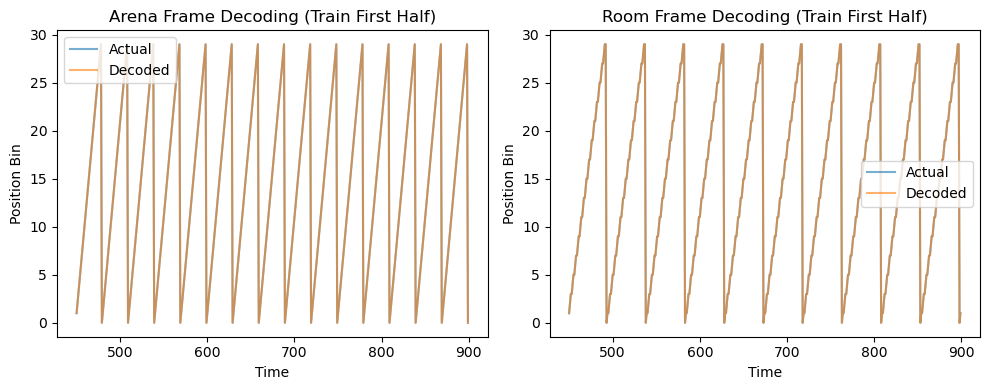

In [11]:
from sklearn.linear_model import LogisticRegression

X = activations_C.T  # shape: (time, neurons)
y_arena = positions_Arena_C
y_room = positions_Room_C

# Split in half
N = X.shape[0]
half = N // 2

X_train, X_test = X[:half], X[half:]
y_arena_train, y_arena_test = y_arena[:half], y_arena[half:]
y_room_train, y_room_test   = y_room[:half],  y_room[half:]

# Train on first half
clf_arena = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000).fit(X_train, y_arena_train)
clf_room  = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000).fit(X_train, y_room_train)

# Predict on second half
decoded_arena_bins = clf_arena.predict(X_test)
decoded_room_bins  = clf_room.predict(X_test)

# Plot predictions vs actual 
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(half, N), y_arena_test, label='Actual', alpha=0.6)
plt.plot(range(half, N), decoded_arena_bins, label='Decoded', alpha=0.6)
plt.title('Arena Frame Decoding (Train First Half)')
plt.xlabel('Time')
plt.ylabel('Position Bin')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(half, N), y_room_test, label='Actual', alpha=0.6)
plt.plot(range(half, N), decoded_room_bins, label='Decoded', alpha=0.6)
plt.title('Room Frame Decoding (Train First Half)')
plt.xlabel('Time')
plt.ylabel('Position Bin')
plt.legend()

plt.tight_layout()
plt.show()


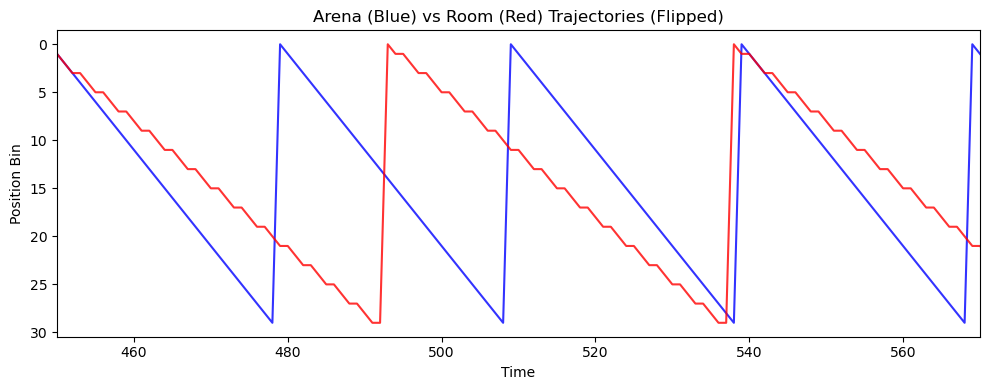

In [12]:
plt.figure(figsize=(10, 4))

# Arena trajectory (blue)
plt.plot(range(half, N), y_arena_test, color='blue', alpha=0.8, label='Arena')

# Room trajectory (red)
plt.plot(range(half, N), y_room_test, color='red', alpha=0.8, label='Room')

plt.title('Arena (Blue) vs Room (Red) Trajectories (Flipped)')
plt.xlabel('Time')
plt.ylabel('Position Bin')
plt.xlim(450, 450+120)

# Flip vertically
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


In [13]:
# Positional Information
n_neurons, n_time = activations_C.shape
position_bins = np.max(positions_Arena_C) + 1  
k_bins = np.linspace(0, 1.4, 50)  

Ipos = np.zeros((n_neurons, position_bins))

# Loop over neurons
for i in range(n_neurons):
    spikes = activations_C[i]                
    positions = positions_Arena_C            

    # Global spike histogram: P(k)
    hist_all, _ = np.histogram(spikes, bins=k_bins, density=True)
    P_k_global = hist_all / np.sum(hist_all) + 1e-12  # small value to avoid log(0)

    # Loop over position bins
    for x in range(position_bins):
        
        # Get spike values when in position x
        spikes_at_x = spikes[positions == x]
        if len(spikes_at_x) < 5:
            continue  

        hist_pos, _ = np.histogram(spikes_at_x, bins=k_bins, density=True)
        P_k_given_x = hist_pos / np.sum(hist_pos) + 1e-12

        # Compute Ipos(x) for neuron i
        ratio = P_k_given_x / P_k_global
        info = P_k_given_x * np.log2(ratio)
        Ipos[i, x] = np.sum(info)


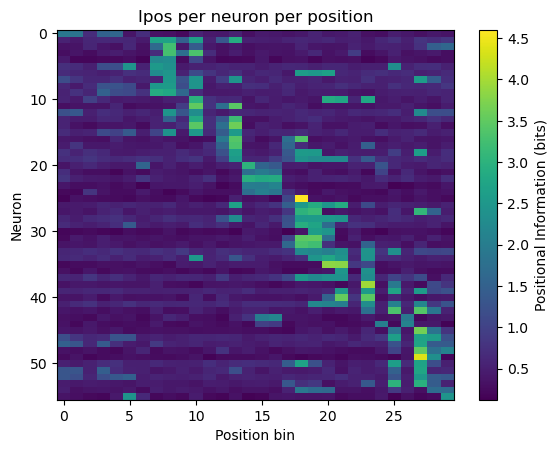

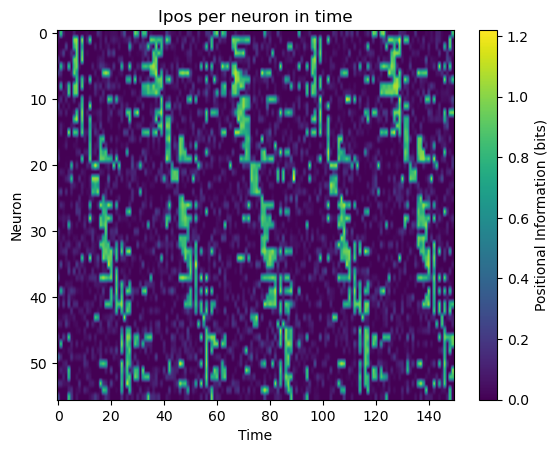

In [14]:
plt.imshow(Ipos[sorted_selected_indices_C_Arena], aspect='auto', cmap='viridis')
plt.colorbar(label='Positional Information (bits)')
plt.xlabel('Position bin')
plt.ylabel('Neuron')
plt.title('Ipos per neuron per position')
plt.show()

plt.imshow(activations_C[sorted_selected_indices_C_Arena,:150], aspect='auto', cmap='viridis')
plt.colorbar(label='Positional Information (bits)')
plt.xlabel('Time')
plt.ylabel('Neuron')
plt.title('Ipos per neuron in time')
plt.show()

In [15]:
# Ensemble IPOS
n_neurons, n_time = activations_C.shape
k_bins = np.linspace(0, 1.4, 30)
k_bin_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
n_bins = np.max(positions_Arena_C) + 1  

Ipos_arena = np.zeros((n_neurons, n_time))
Ipos_room = np.zeros((n_neurons, n_time))
EnIpos_arena  = np.zeros(n_time)
EnIpos_room  = np.zeros(n_time)

# Loop over neurons
for i in range(n_neurons):
    spikes = activations_C[i]  # (time,)

    # Global spike histogram
    Pk_global, _ = np.histogram(spikes, bins=k_bins, density=True)
    Pk_global /= Pk_global.sum() + 1e-12

    # P(k | x) for each position bin
    Pk_given_x_arena = np.zeros((n_bins, len(k_bin_centers)))
    Pk_given_x_room = np.zeros((n_bins, len(k_bin_centers)))

    for x in range(n_bins):
        idx_arena = np.where(positions_Arena_C == x)[0]
        idx_room = np.where(positions_Room_C == x)[0]

        if len(idx_arena) > 5:
            h_arena, _ = np.histogram(spikes[idx_arena], bins=k_bins, density=True)
            Pk_given_x_arena[x] = h_arena / (h_arena.sum() + 1e-12)
        if len(idx_room) > 5:
            h_room, _ = np.histogram(spikes[idx_room], bins=k_bins, density=True)
            Pk_given_x_room[x] = h_room / (h_room.sum() + 1e-12)

    # Compute moment-by-moment Ipos
    for t in range(n_time):
        k_t = spikes[t]
        bin_idx = np.argmin(np.abs(k_bin_centers - k_t))  # closest k bin

        x_arena = positions_Arena_C[t]
        x_room = positions_Room_C[t]

        Pk_arena = Pk_given_x_arena[x_arena, bin_idx]
        Pk_room  = Pk_given_x_room[x_room, bin_idx]
        Pk = Pk_global[bin_idx]

        if Pk > 0:
            if Pk_arena > 0:
                Ipos_arena[i, t] = Pk_arena * np.log2(Pk_arena / Pk)
                EnIpos_arena[t] = np.sum(Ipos_arena[:,t])

            if Pk_room > 0:
                Ipos_room[i, t] = Pk_room * np.log2(Pk_room / Pk)
                EnIpos_room[t] = np.sum(Ipos_room[:,t])



In [16]:
# Compute Room vs Arena difference
Ipos_diff = Ipos_room - Ipos_arena  
EnIpos_diff = EnIpos_room - EnIpos_arena  


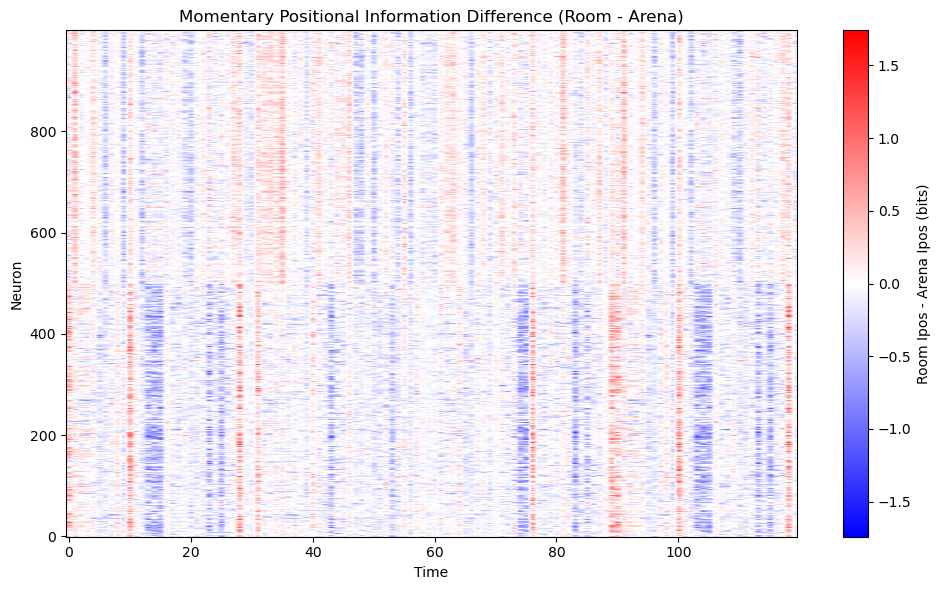

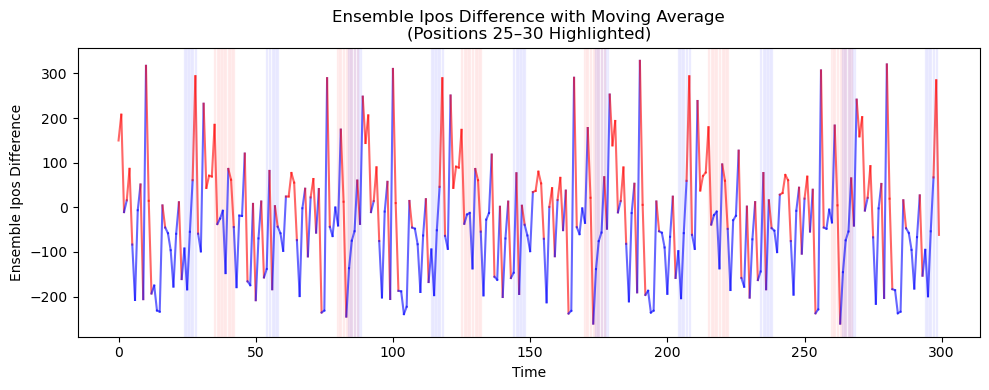

In [17]:
plt.figure(figsize=(10, 6))
plt.imshow(Ipos_diff[:,:120], aspect='auto', origin='lower', cmap='bwr', vmin=-np.max(np.abs(Ipos_diff)), vmax=np.max(np.abs(Ipos_diff)))
plt.colorbar(label='Room Ipos - Arena Ipos (bits)')
plt.xlabel('Time')
plt.ylabel('Neuron')
plt.title('Momentary Positional Information Difference (Room - Arena)')
plt.tight_layout()
plt.show()


Duration = 300
window_size = 5  

# Compute moving average
kernel = np.ones(window_size) / window_size
moving_avg = np.convolve(EnIpos_diff[:Duration], kernel, mode='same')
plt.figure(figsize=(10, 4))

for i in range(Duration - 1):
    x = [i, i+1]
    y = [EnIpos_diff[i], EnIpos_diff[i+1]]
    color = 'red' if EnIpos_diff[i] > 0 else 'blue'
    plt.plot(x, y, color=color, alpha=0.6)


# Highlight times when position is near landmark
room_times = np.where((positions_Room_C[:Duration] >= 25) & (positions_Room_C[:Duration] <= 30))[0]
arena_times = np.where((positions_Arena_C[:Duration] >= 25) & (positions_Arena_C[:Duration] <= 30))[0]

for t in room_times:
    plt.axvspan(t - 0.25, t + 0.25, color='red', alpha=0.05)
for t in arena_times:
    plt.axvspan(t - 0.25, t + 0.25, color='blue', alpha=0.05)

plt.title("Ensemble Ipos Difference with Moving Average\n(Positions 25–30 Highlighted)")
plt.xlabel("Time")
plt.ylabel("Ensemble Ipos Difference")
plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


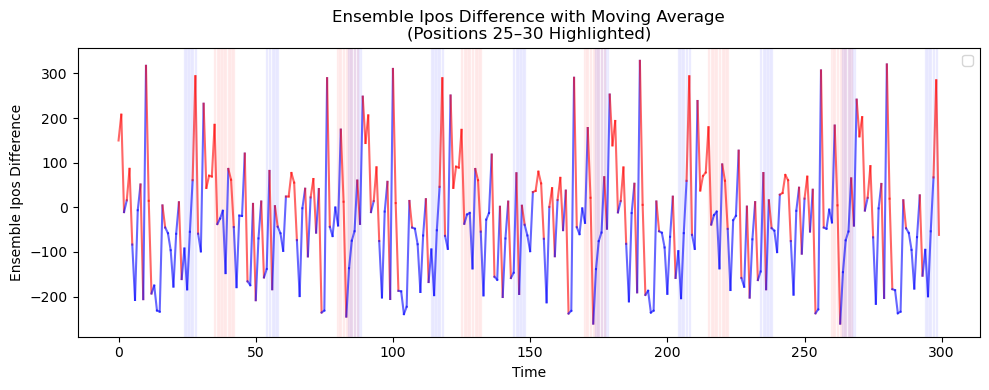

In [18]:

Duration = 300
window_size = 5  

# Compute moving average
kernel = np.ones(window_size) / window_size
moving_avg = np.convolve(EnIpos_diff[:Duration], kernel, mode='same')

fig = plt.figure(figsize=(10, 4))

for i in range(Duration - 1):
    x = [i, i + 1]
    y = [EnIpos_diff[i], EnIpos_diff[i + 1]]
    color = 'red' if EnIpos_diff[i] > 0 else 'blue'
    plt.plot(x, y, color=color, alpha=0.6)

# Highlight times when position is near landmark
room_times = np.where((positions_Room_C[:Duration] >= 25) & (positions_Room_C[:Duration] <= 30))[0]
arena_times = np.where((positions_Arena_C[:Duration] >= 25) & (positions_Arena_C[:Duration] <= 30))[0]

for t in room_times:
    plt.axvspan(t - 0.25, t + 0.25, color='red', alpha=0.05)
for t in arena_times:
    plt.axvspan(t - 0.25, t + 0.25, color='blue', alpha=0.05)

plt.title("Ensemble Ipos Difference with Moving Average\n(Positions 25–30 Highlighted)")
plt.xlabel("Time")
plt.ylabel("Ensemble Ipos Difference")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
2

2

In [20]:
Neurons_Selected_Arena = sorted_selected_indices_C_Arena
Neurons_Selected_Room = sorted_selected_indices_C_Room
Neurons_Selected = np.unique(np.concatenate([Neurons_Selected_Arena, Neurons_Selected_Room]))

# Setup
n_neurons, n_time = activations_C.shape
k_bins = np.linspace(0, 1.4, 30)
k_bin_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
n_bins = np.max(positions_Arena_C) + 1  

# Smooth activations 
smoothed_activations = np.apply_along_axis(
    lambda x: np.convolve(x, np.ones(5)/5, mode='same'),
    axis=1,
    arr=activations_C
)

Ipos_arena = np.zeros((len(Neurons_Selected), n_time))
Ipos_room = np.zeros((len(Neurons_Selected), n_time))
EnIpos_arena = np.zeros(n_time)
EnIpos_room = np.zeros(n_time)

for n_idx, i in enumerate(Neurons_Selected):
    spikes = smoothed_activations[i]

    # Global spike histogram
    Pk_global, _ = np.histogram(spikes, bins=k_bins, density=True)
    Pk_global /= Pk_global.sum() + 1e-12

    #P(k | x)
    Pk_given_x_arena = np.zeros((n_bins, len(k_bin_centers)))
    Pk_given_x_room  = np.zeros((n_bins, len(k_bin_centers)))

    for x in range(n_bins):
        idx_arena = np.where(positions_Arena_C == x)[0]
        idx_room  = np.where(positions_Room_C == x)[0]

        if len(idx_arena) > 5:
            h_arena, _ = np.histogram(spikes[idx_arena], bins=k_bins, density=True)
            Pk_given_x_arena[x] = h_arena / (h_arena.sum() + 1e-12)
        if len(idx_room) > 5:
            h_room, _ = np.histogram(spikes[idx_room], bins=k_bins, density=True)
            Pk_given_x_room[x] = h_room / (h_room.sum() + 1e-12)

    # Moment-by-moment Ipos
    for t in range(n_time):
        k_t = spikes[t]
        bin_idx = np.argmin(np.abs(k_bin_centers - k_t))

        x_arena = positions_Arena_C[t]
        x_room  = positions_Room_C[t]

        Pk_arena = Pk_given_x_arena[x_arena, bin_idx]
        Pk_room  = Pk_given_x_room[x_room, bin_idx]
        Pk       = Pk_global[bin_idx]

        if Pk > 0:
            if Pk_arena > 0:
                Ipos_arena[n_idx, t] = Pk_arena * np.log2(Pk_arena / Pk)
            if Pk_room > 0:
                Ipos_room[n_idx, t] = Pk_room * np.log2(Pk_room / Pk)

EnIpos_arena = np.sum(Ipos_arena, axis=0)
EnIpos_room  = np.sum(Ipos_room, axis=0)
EnIpos_diff  = EnIpos_room - EnIpos_arena
Ipos_diff = Ipos_room - Ipos_arena  # shape: (neurons, time)


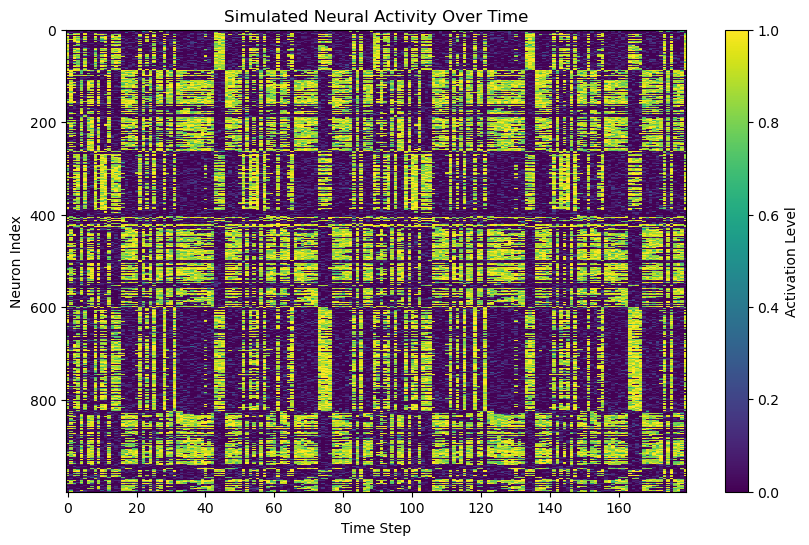

In [21]:


Start=360
End=540


# Visualize the activations using imshow()
fig=plt.figure(figsize=(10, 6))
plt.imshow(activations_combined[indices_peak_A,Start:End], aspect='auto', cmap='viridis', interpolation='none',vmin=0,vmax=1)
plt.colorbar(label='Activation Level')
plt.xlabel('Time Step')
plt.ylabel('Neuron Index')
plt.title('Simulated Neural Activity Over Time')
plt.show()


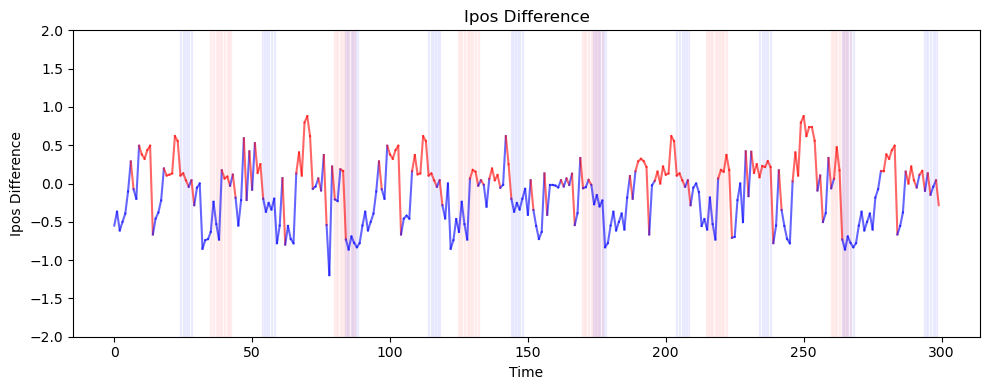

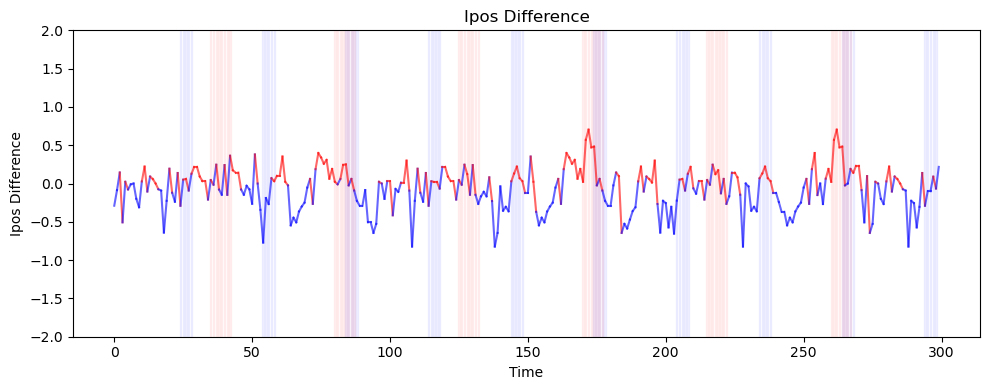

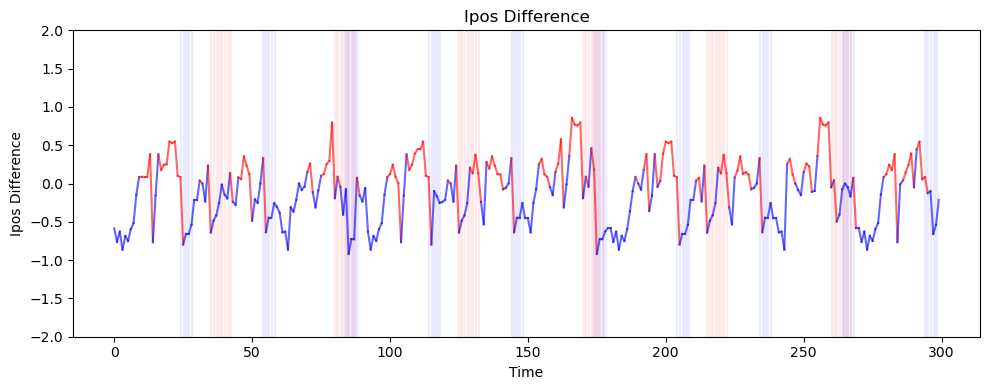

In [22]:
Neu = 0
Ipos_diff = Ipos_room - Ipos_arena  # shape: (neurons, time)
Duration = 300
window_size = 5

kernel = np.ones(window_size) / window_size
moving_avg = np.convolve(Ipos_diff[Neu, :Duration], kernel, mode='same')

fig = plt.figure(figsize=(10, 4))
for i in range(Duration - 1):
    x = [i, i + 1]
    y = [Ipos_diff[Neu, i], Ipos_diff[Neu, i + 1]]
    color = 'red' if Ipos_diff[Neu, i] > 0 else 'blue'
    plt.plot(x, y, color=color, alpha=0.6)

room_times = np.where((positions_Room_C[:Duration] >= 25) & (positions_Room_C[:Duration] <= 30))[0]
arena_times = np.where((positions_Arena_C[:Duration] >= 25) & (positions_Arena_C[:Duration] <= 30))[0]

for t in room_times:
    plt.axvspan(t - 0.25, t + 0.25, color='red', alpha=0.05)
for t in arena_times:
    plt.axvspan(t - 0.25, t + 0.25, color='blue', alpha=0.05)

plt.title("Ipos Difference")
plt.xlabel("Time")
plt.ylabel("Ipos Difference")
plt.ylim(-2, 2)
plt.tight_layout()
plt.show()

# --------------------------------------

Neu = 6
moving_avg = np.convolve(Ipos_diff[Neu, :Duration], kernel, mode='same')

fig = plt.figure(figsize=(10, 4))
for i in range(Duration - 1):
    x = [i, i + 1]
    y = [Ipos_diff[Neu, i], Ipos_diff[Neu, i + 1]]
    color = 'red' if Ipos_diff[Neu, i] > 0 else 'blue'
    plt.plot(x, y, color=color, alpha=0.6)

room_times = np.where((positions_Room_C[:Duration] >= 25) & (positions_Room_C[:Duration] <= 30))[0]
arena_times = np.where((positions_Arena_C[:Duration] >= 25) & (positions_Arena_C[:Duration] <= 30))[0]

for t in room_times:
    plt.axvspan(t - 0.25, t + 0.25, color='red', alpha=0.05)
for t in arena_times:
    plt.axvspan(t - 0.25, t + 0.25, color='blue', alpha=0.05)

plt.title("Ipos Difference")
plt.xlabel("Time")
plt.ylabel("Ipos Difference")
plt.ylim(-2, 2)
plt.tight_layout()
plt.show()

# --------------------------------------

Neu = 4
moving_avg = np.convolve(Ipos_diff[Neu, :Duration], kernel, mode='same')

fig = plt.figure(figsize=(10, 4))
for i in range(Duration - 1):
    x = [i, i + 1]
    y = [Ipos_diff[Neu, i], Ipos_diff[Neu, i + 1]]
    color = 'red' if Ipos_diff[Neu, i] > 0 else 'blue'
    plt.plot(x, y, color=color, alpha=0.6)

room_times = np.where((positions_Room_C[:Duration] >= 25) & (positions_Room_C[:Duration] <= 30))[0]
arena_times = np.where((positions_Arena_C[:Duration] >= 25) & (positions_Arena_C[:Duration] <= 30))[0]

for t in room_times:
    plt.axvspan(t - 0.25, t + 0.25, color='red', alpha=0.05)
for t in arena_times:
    plt.axvspan(t - 0.25, t + 0.25, color='blue', alpha=0.05)

plt.title("Ipos Difference")
plt.xlabel("Time")
plt.ylabel("Ipos Difference")
plt.ylim(-2, 2)
plt.tight_layout()
plt.show()


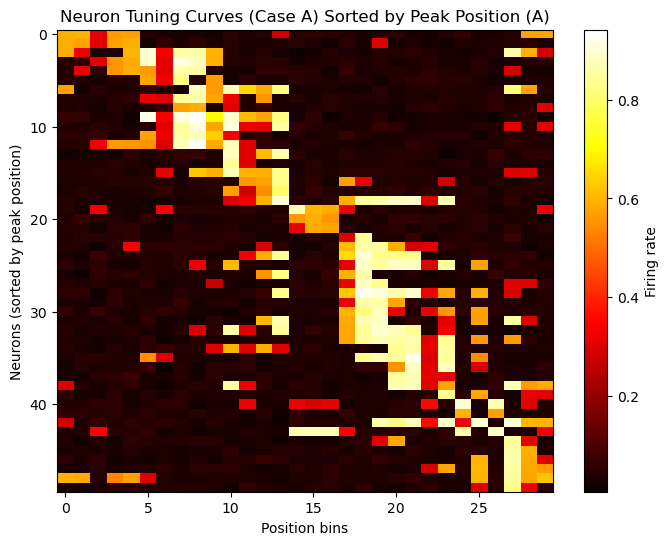

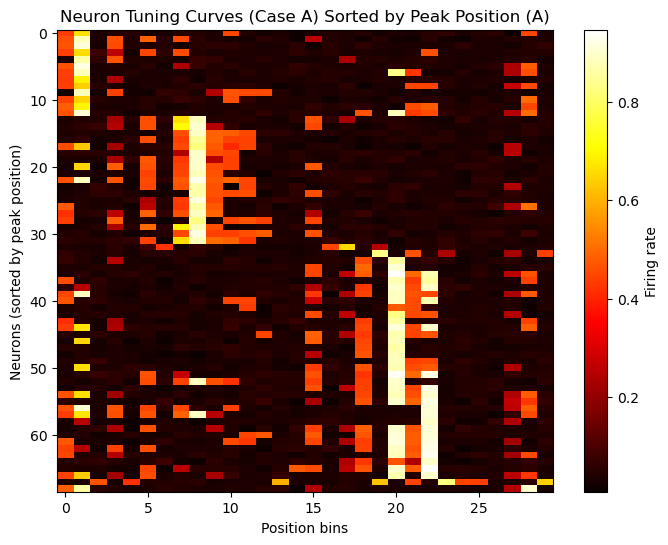

In [24]:

# Plot tuning curves for Case A sorted by A
fig=plt.figure(figsize=(8, 6))
plt.imshow(tuning_curves_A_Arena[ArenaFrame_Place, :], aspect='auto', cmap='hot', interpolation='nearest')
plt.xlabel("Position bins")
plt.ylabel("Neurons (sorted by peak position)")
plt.colorbar(label="Firing rate")
plt.title("Neuron Tuning Curves (Case A) Sorted by Peak Position (A)")
plt.show()

# Plot tuning curves for Case A sorted by A
fig=plt.figure(figsize=(8, 6))
plt.imshow(tuning_curves_A_Room[RoomFrame_Place, :], aspect='auto', cmap='hot', interpolation='nearest')
plt.xlabel("Position bins")
plt.ylabel("Neurons (sorted by peak position)")
plt.colorbar(label="Firing rate")
plt.title("Neuron Tuning Curves (Case A) Sorted by Peak Position (A)")
plt.show()